# **Simulation Hedy 2025**

Team: TU Wien Space Team \
Project: Lamarr \
Rocket: Hedy \
Launched on 12.10.2025 at EuRoC


## Installs

In this section all needed libraries are installed and the needed classes imported

In [30]:
%pip install rocketpy==1.5.0

Defaulting to user installation because normal site-packages is not writeable
  Attempting uninstall: rocketpy
    Found existing installation: rocketpy 1.11.0
    Uninstalling rocketpy-1.11.0:
      Successfully uninstalled rocketpy-1.11.0
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\wattikan\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
%pip install CoolProp

In [6]:
from rocketpy import Environment, Rocket, Flight, SolidMotor, NoseCone, Tail, Parachute, TrapezoidalFins
import numpy as np
from math import pi

## Configuration

The length unit chosen here is millimeters to keep the values more readable. If necessary, values should be converted accordingly.

In [3]:
# Rocket configuration data
#
env_config = {
    "date" : (2026, 4, 9, 17, 00, 00),  # yyyy, mm, dd, hh, mm, ss    # preset
    "latitude" : 48.235693,               # Launch latitude             # preset
    "longitude" : 13.271437,              # Launch longitude            # preset
    "max_height" : 2000,                  # m                           # preset    
    "timezone" : "Europe/Rome"          # GMT+1                       # preset
}

motor_config = {
    "name": "K700W",
    "total_mass": 2035 /1000,        # kg
    "propellant_mass": 1303 /1000,   # kg
    "radius": 54 /1000 /2,           # kg
    "length": 568 /1000,             # m
    "burn_time": 3.5                 # s
}

rocket_config = {
    "total_weight" : 17486,               # g       # weighed dry mass
    "total_length" : 3764,                # mm      # measured
    "total_CG" : 1813,                    # mm      # measured      # FROM TIP!
    "moment_of_intertia_Z" : 0.0388,      # kg*m^2  # calculated
    "moment_of_intertia_XY" : 21.45,       # kg*m^2  # calculated
    "nosecone" : {
        "length" : 561,                   # mm      # measured    # 575 + 66 - 80 = 561
        "kind" : "lv haack"
    },
    "railbuttons" : {
        "upper" : 1646,                   # mm      # measured
        "lower" : 305                     # mm      # measured
    },
    "tailcone" : {
        "diameter" : 108,                 # mm      # measured
        "length" : 245,                   # mm      # measured
        "cylindrical_height" : 35         # mm      # measured
    },
    "rocket" : {
        "thickness" : 1.4,                # mm      # measured
        "diameter" : 132.8                # mm      # measured
    },
    "fins" : {
        "name" : "Biconvex-Freeform",
        "amount" : 4,
        "position" : 250,                 # mm      # measured
        "shape_points" : ((0,0),
                          (0.250,-0.012),
                          (0.250, 0.108),
                          (0.195, 0.108),
                          (0,0))          # m       # measured
    },
    "parachutes" : {
        "main" : {
            "cd_s" : 6.911503837897546,                     # calculated
            "trigger" : 250,              # m               # preset
            "sampling_rate" : 105,        # hz              # preset
            "lag" : 4,                    # s               # measured
            "noise" : (0, 8.3, 0.5)       # (pa, pa, pa)    # preset
        },
        "drogue" : {
            "cd_s" : 0.5336875,
            "trigger" : "apogee",         # m               # preset
            "sampling_rate" : 105,        # hz              # preset
            "lag" : 1,                    # s               # measured
            "noise" : (0, 8.3, 0.5)       # (pa, pa, pa)    # preset
        }
    }
}
flight_config = {
    "rail_length" : 8,                   # m       #Preset
    "inclination" : 84,                   # °       #Preset
    "heading" : 184,                      # °       #Preset
    "terminate_on_apogee" : True
}

## Environments Initialization




In this section the environments are initialized.
*   **envReanalysis**: environment with the weather data from the location and date of EuRoc'25


Fetching elevation from open-elevation.com for lat=48.235693, lon=13.271437...
Elevation received: 376.0 m

Gravity Details

Acceleration of gravity at surface level:    9.7792 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5379 m/s²


Launch Site Details

Launch Date: 2026-04-09 15:00:00 UTC | 2026-04-09 17:00:00 Europe/Rome
Launch Site Latitude: 48.23569°
Launch Site Longitude: 13.27144°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 166021.44 W|E    0.00 N
Launch Site UTM zone: 31N
Launch Site Surface Elevation: 376.0 m


Atmospheric Model Details

Atmospheric Model Type: standard_atmosphere
standard_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 0.00 m/s
Surface Wind Direction: 0.00°
Surface Wind Heading: 0.00°
Surface Pressure: 969.25 hPa
Surface Temperature: 285.71 K
Surface Air Density: 1.182 kg/m³
Surface Speed of Sound: 338.75 m/s


Earth Model Details

Earth Radius at Launch site: 6378.14 km
Semi-major Axis: 6378.14 km

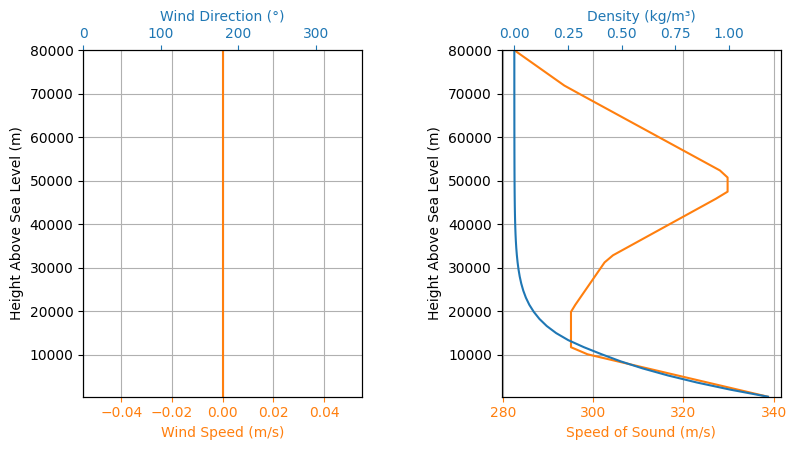

In [4]:
#Ponte de Sor: 39.12368, -8.03333
#launch date: 12.10.2025, 17:00


latitude    = env_config["latitude"]
longitude   = env_config["longitude"]
timezone    = env_config["timezone"]
date        = env_config["date"]
max_height  = env_config["max_height"]

#Environment based on Forecast data for the EuRoC 2024
envForecast = Environment(max_expected_height = max_height)
envForecast.set_location(latitude = latitude, longitude = longitude)
envForecast.set_elevation("Open-Elevation") # 351m
envForecast.set_date(date, timezone = timezone)
envForecast.set_atmospheric_model(type = "standard_atmosphere")
envForecast.info()

## Simulation

### Engine



Nozzle Details
Nozzle Radius: 0.027 m
Nozzle Throat Radius: 0.0135 m

Grain Details
Number of Grains: 1
Grain Spacing: 0 m
Grain Density: 1001.6561894971871 kg/m3
Grain Outer Radius: 0.027 m
Grain Inner Radius: 0 m
Grain Height: 0.568 m
Grain Volume: 0.001 m3
Grain Mass: 1.303 kg

Motor Details
Total Burning Time: 3.5 s
Total Propellant Mass: 1.303 kg
Average Propellant Exhaust Velocity: 1751.895 m/s
Average Thrust: 652.205 N
Maximum Thrust: 1029.337 N at 0.632 s after ignition.
Total Impulse: 2282.719 Ns



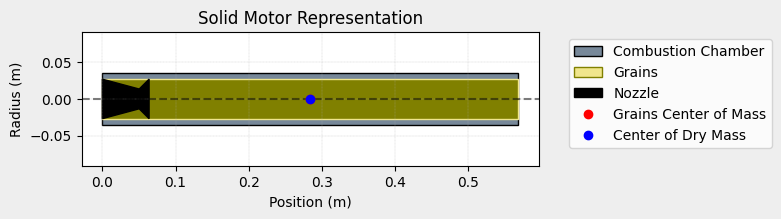

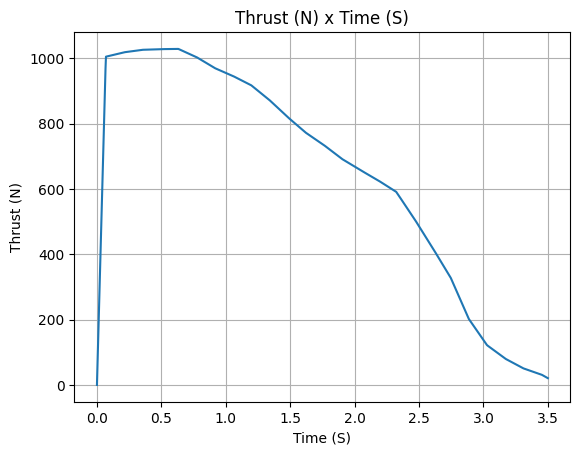

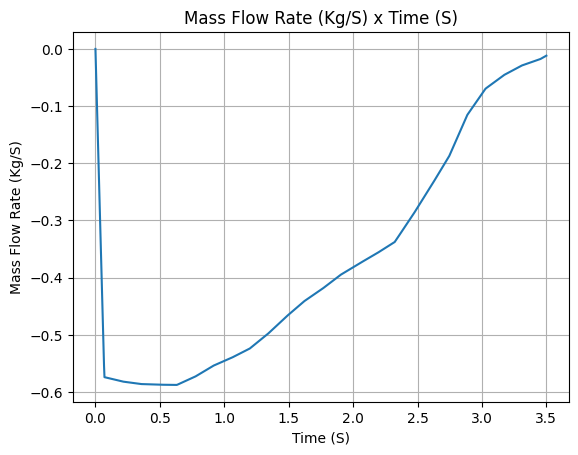

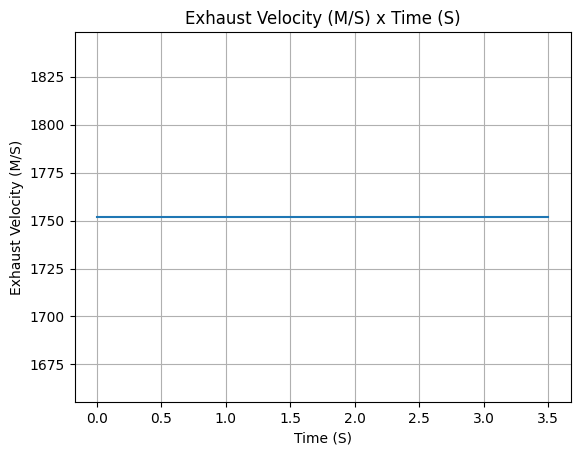

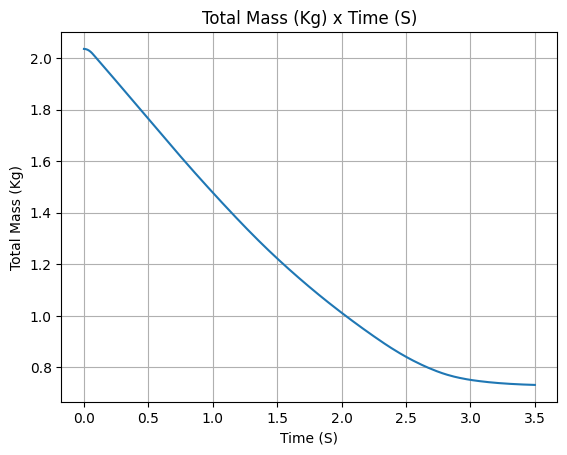

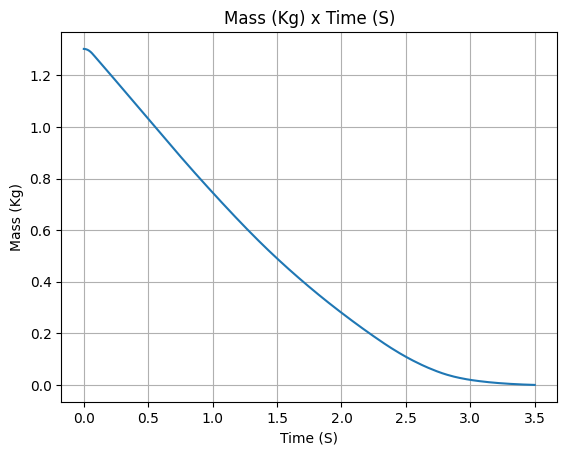

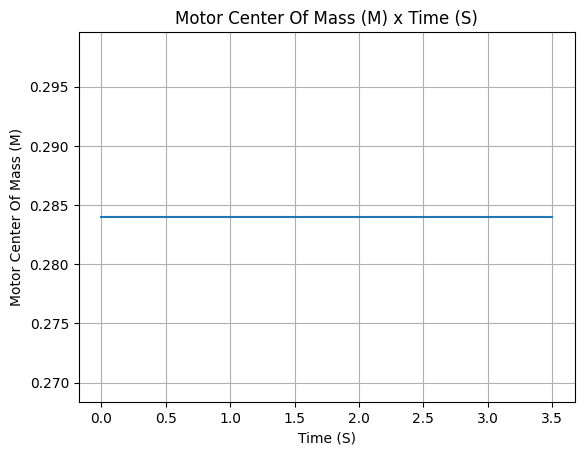

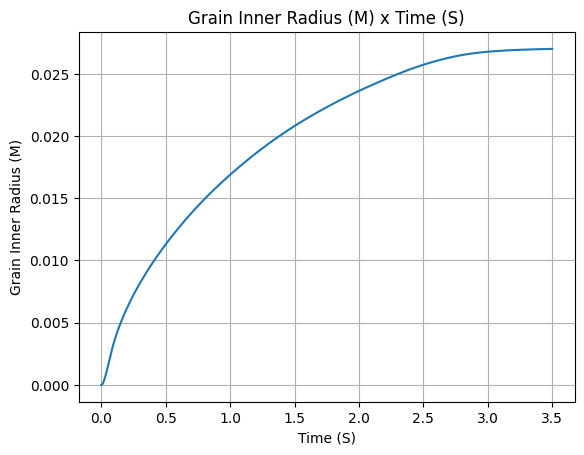

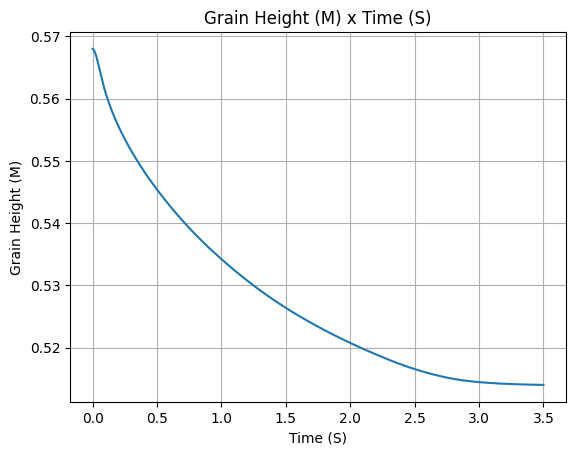

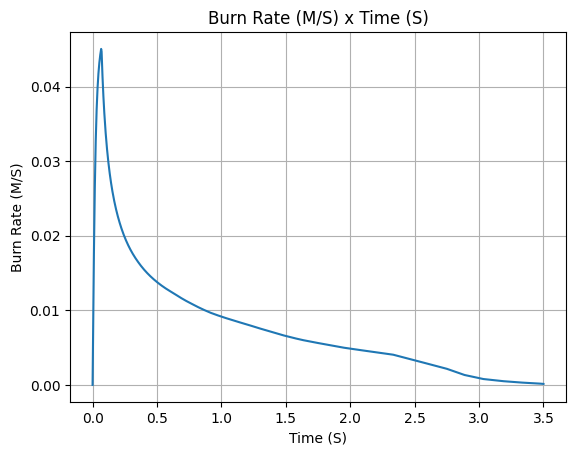

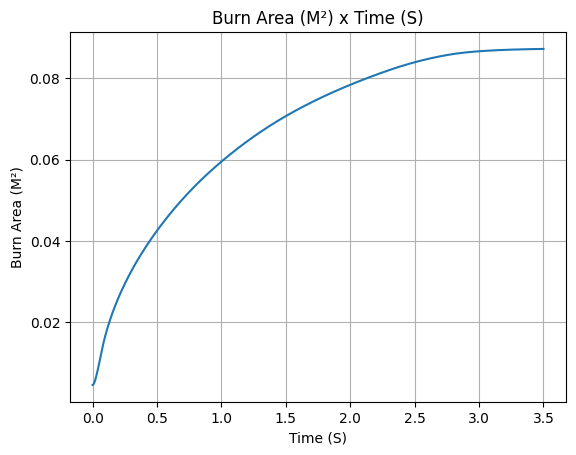

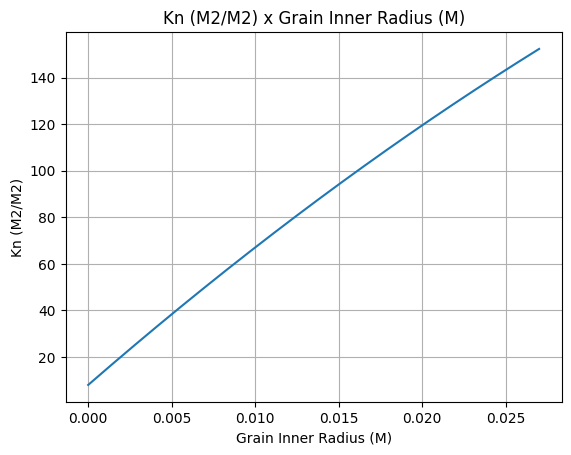

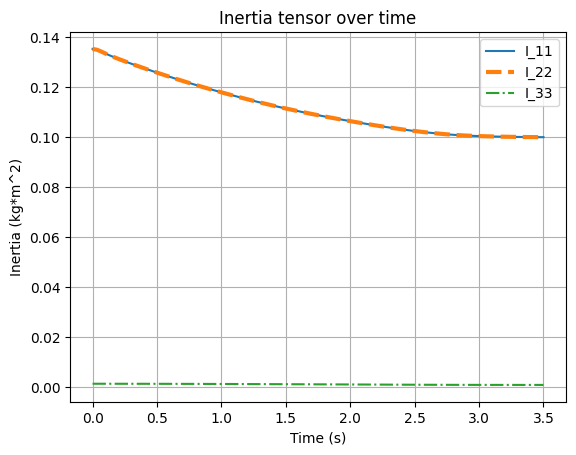

In [5]:
motor_total_mass        = motor_config["total_mass"]                  #kg
motor_propellant_mass   = motor_config["propellant_mass"]             #kg
motor_radius            = motor_config["radius"]                      #kg
motor_length            = motor_config["length"]                      #m
motor_volume            = pi * (motor_radius ** 2) * motor_length     #m³
motor_grain_density     = motor_propellant_mass/motor_volume          #kg/m³
motor_burn_time         = motor_config["burn_time"]

k700w = SolidMotor(
  thrust_source                   = "AeroTech_K700W.eng",
  dry_mass                        = motor_total_mass - motor_propellant_mass,
  dry_inertia                     = (0.1, 0.1, 0.001),                        #kg*m²   #guess / not so relevant
  nozzle_radius                   = motor_radius,
  grain_number                    = 1,
  grain_density                   = motor_grain_density,
  grain_outer_radius              = motor_radius,
  grain_initial_inner_radius      = 0,
  grain_initial_height            = motor_length,
  grain_separation                = 0,
  grains_center_of_mass_position  = motor_length / 2,
  center_of_dry_mass_position     = motor_length / 2,
  nozzle_position                 = 0,
  burn_time                       = motor_burn_time,
  throat_radius                   = motor_radius / 2,
  coordinate_system_orientation   = "nozzle_to_combustion_chamber",
)
k700w.all_info()

### Rocket components

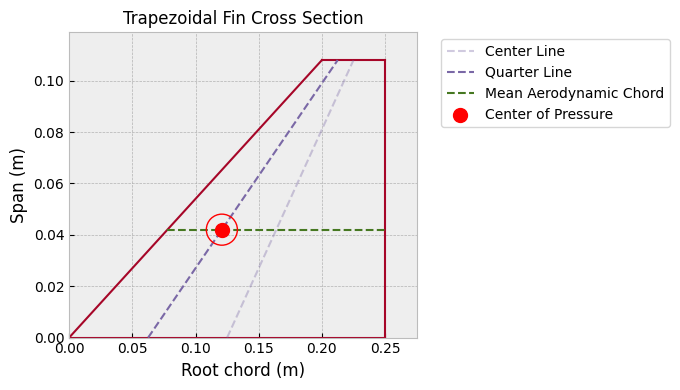

In [10]:
#rocket
rocket_length     = rocket_config["total_length"]         / 1000
rocket_diameter   = rocket_config["rocket"]["diameter"]   / 1000
rocket_thickness  = rocket_config["rocket"]["thickness"]  / 1000


nosecone_length = (rocket_config["nosecone"]["length"]-80)    / 1000   # -80 mm to adjust for cylindrical section
nosecone_kind = rocket_config["nosecone"]["kind"]

nose_cone = NoseCone(
    length = nosecone_length,
    base_radius = rocket_diameter/2,
    kind = nosecone_kind
)

tailcone_cylindrical    = rocket_config["tailcone"]["cylindrical_height"] / 1000
tailcone_length         = rocket_config["tailcone"]["length"]             / 1000
tailcone_bottom_radius  = rocket_config["tailcone"]["diameter"]        /2 / 1000

tail = Tail(
    top_radius = rocket_diameter /2,
    bottom_radius = tailcone_bottom_radius,
    length = tailcone_length,
    rocket_radius = rocket_diameter/2
)

fin_amount        = rocket_config["fins"]["amount"]
fin_shape_points  = rocket_config["fins"]["shape_points"]
fin_name          = rocket_config["fins"]["name"]

#fin_set = FreeFormFins(
#   n = fin_amount,
#   shape_points = fin_shape_points,
#   rocket_radius=tailcone_bottom_radius,
#   name = fin_name
#)
#fin_set.draw()

fin_set = TrapezoidalFins(
      n             = fin_amount,
      root_chord    = 0.250,
      tip_chord     = 0.050,
      span          = 0.108,
      sweep_length  = 0.200,
      rocket_radius = tailcone_bottom_radius,
      name          = "Trapezoidal"
)
fin_set.draw()

main_cd_s               = rocket_config["parachutes"]["drogue"]["cd_s"]                   # main didn't deploy fully, so adding another drogue as approximation
main_trigger            = rocket_config["parachutes"]["main"]["trigger"]
main_sampling_rate      = rocket_config["parachutes"]["main"]["sampling_rate"]
main_lag                = rocket_config["parachutes"]["main"]["lag"]
main_noise              = rocket_config["parachutes"]["main"]["noise"]

drogue_cd_s             = rocket_config["parachutes"]["drogue"]["cd_s"]
drogue_trigger          = rocket_config["parachutes"]["drogue"]["trigger"]
drogue_sampling_rate    = rocket_config["parachutes"]["drogue"]["sampling_rate"]
drogue_lag              = rocket_config["parachutes"]["drogue"]["lag"]
drogue_noise            = rocket_config["parachutes"]["drogue"]["noise"]

parachutes = {}

parachutes[0] = Parachute(
    name = "main",
    cd_s = main_cd_s,
    trigger = main_trigger,
    sampling_rate = main_sampling_rate,
    lag = main_lag,
    noise = main_noise
)

parachutes[1] = Parachute(
    name = "drogue",
    cd_s = drogue_cd_s,
    trigger = drogue_trigger,
    sampling_rate = drogue_sampling_rate,
    lag = drogue_lag,
    noise = drogue_noise
)


### Hedy


Inertia Details

Rocket Mass: 17.486 kg (without motor)
Rocket Dry Mass: 18.218 kg (with unloaded motor)
Rocket Loaded Mass: 19.521 kg
Rocket Inertia (with unloaded motor) 11: 23.502 kg*m2
Rocket Inertia (with unloaded motor) 22: 23.502 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.040 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0664 m
Rocket Frontal Area: 0.013851 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.067 m
Rocket Center of Dry Mass - Nozzle Exit: 1.884 m
Rocket Center of Dry Mass - Center of Propellant Mass: 1.600 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.107 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Trapezoidal Lift Coefficient Derivative: 5.876/rad
Tail Lift Coefficient Derivative: -0.677/rad

Cente

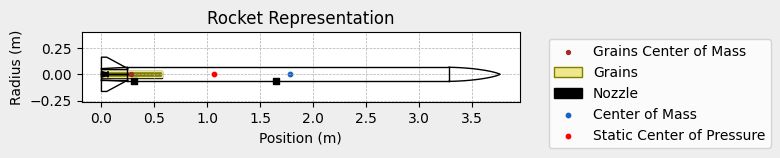


Mass Plots
----------------------------------------


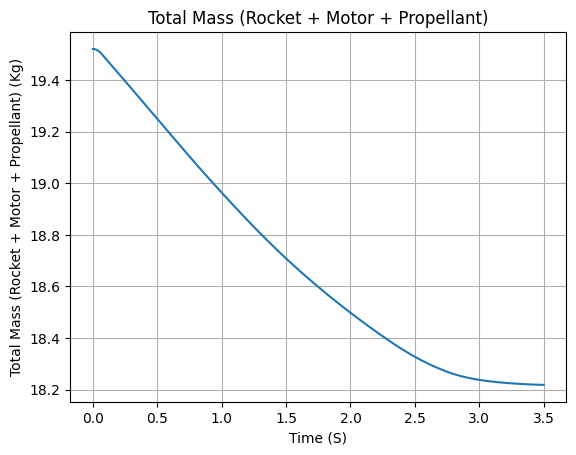

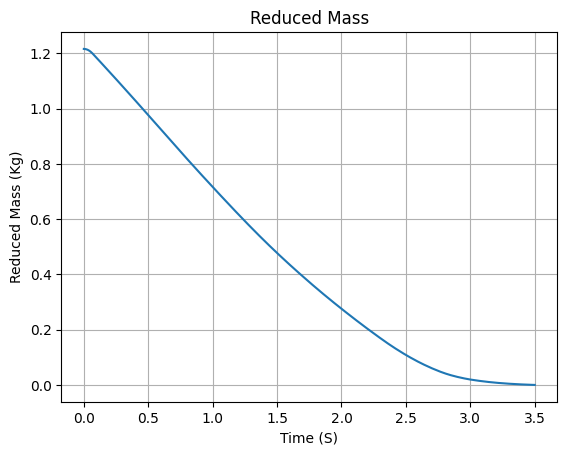


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


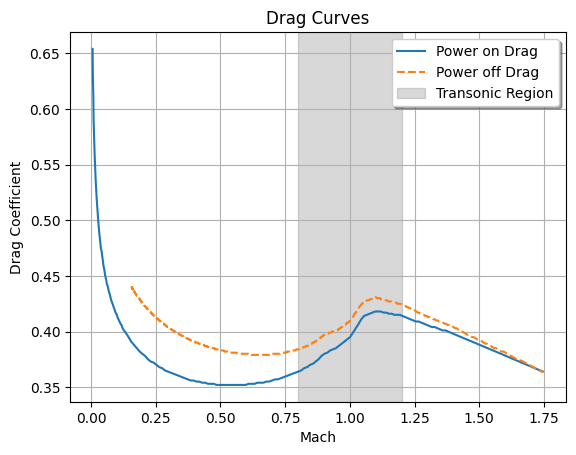


Stability Plots
--------------------


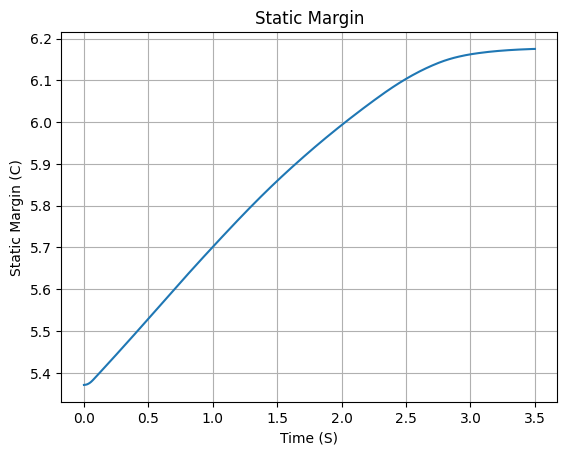

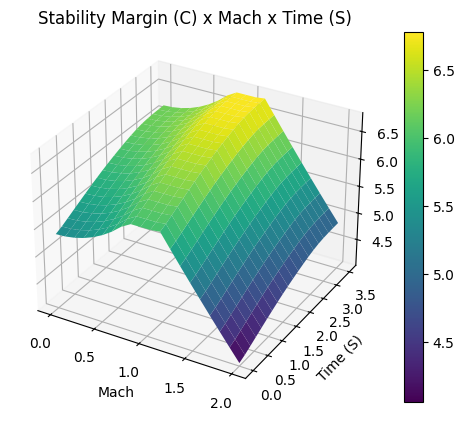


Thrust-to-Weight Plot
----------------------------------------


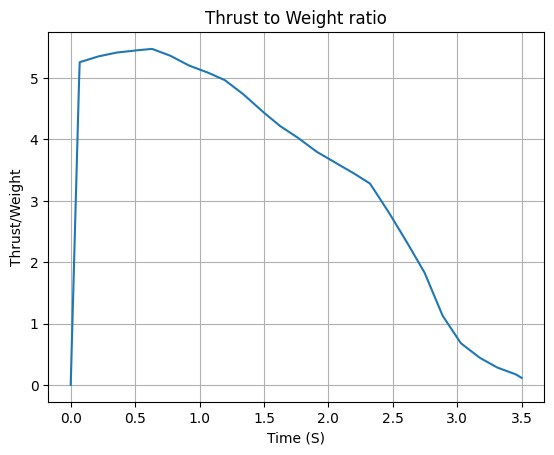

In [11]:

total_mass        = rocket_config["total_weight"] / 1000

#inertia
inertia_x_y   = rocket_config["moment_of_intertia_XY"]
inertia_z     = rocket_config["moment_of_intertia_Z"]

upper_railbutton_position   = rocket_config["railbuttons"]["upper"] / 1000
lower_railbutton_position   = rocket_config["railbuttons"]["lower"] / 1000
fin_position                = rocket_config["fins"]["position"]     / 1000

total_CG = rocket_config["total_CG"] / 1000

hedy = Rocket(
    radius = rocket_diameter /2,
    mass = total_mass,
    inertia = (inertia_x_y, inertia_x_y, inertia_z),
    power_off_drag = "./power_off_drag.csv",
    power_on_drag = "./power_on_drag.csv",
    center_of_mass_without_motor = rocket_length-total_CG,
    coordinate_system_orientation = "tail_to_nose"
)


hedy.add_motor(k700w, position = 0)


hedy.set_rail_buttons(upper_button_position= upper_railbutton_position, lower_button_position=lower_railbutton_position)

hedy.add_surfaces(surfaces=[nose_cone, fin_set, tail], positions=[rocket_length, fin_position, tailcone_length])

hedy.parachutes = list(parachutes.values())

hedy.all_info()

### Flight

Takeoff Mass: 19.199146502223396

Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 376.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.350 | e1: 0.022 | e2: 0.048 | e3: -0.935
Euler Angles - Spin φ : 45.00° | Nutation θ: -6.00° | Precession ψ: -184.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 5.371 c


Surface Wind Conditions

Frontal Surface Wind Speed: -0.00 m/s
Lateral Surface Wind Speed: -0.00 m/s


Launch Rail

Launch Rail Length: 8 m
Launch Rail Inclination: 84.00°
Launch Rail Heading: 184.00°


Rail Departure State

Rail Departure Time: 0.587 s
Rail Departure Velocity: 23.462 m/s
Rail Departure Stability Margin: 5.563 c
Rail Departure Angle of Attack: 0.000°
Rail Departure Thrust-Weight Ratio: 5.466
Rail Departure Reynolds Number: 2.071e+05


Burn out State

Burn out time: 3.500 s
Altitude at burn out: 580.023 m (ASL) | 204.023 m (AGL)
Rocket speed at bur

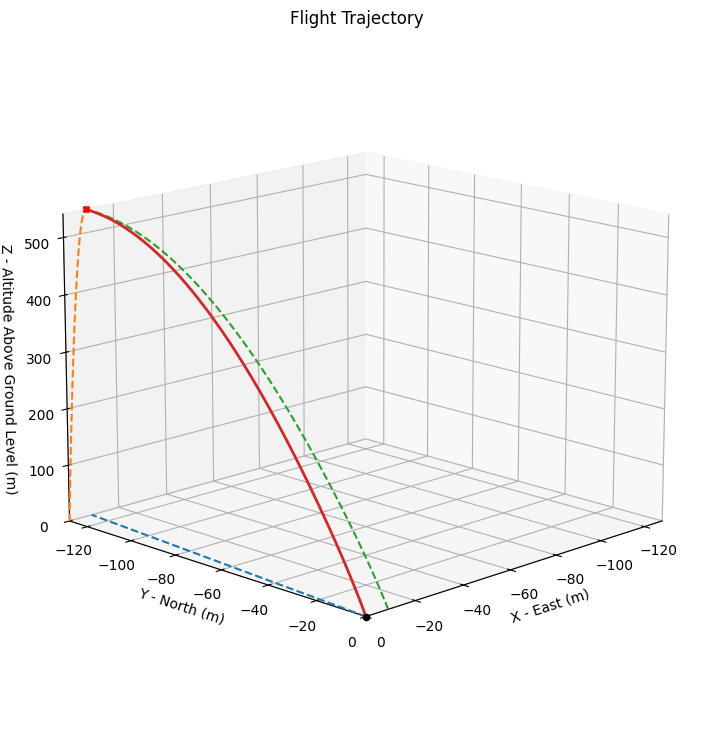



Trajectory Kinematic Plots



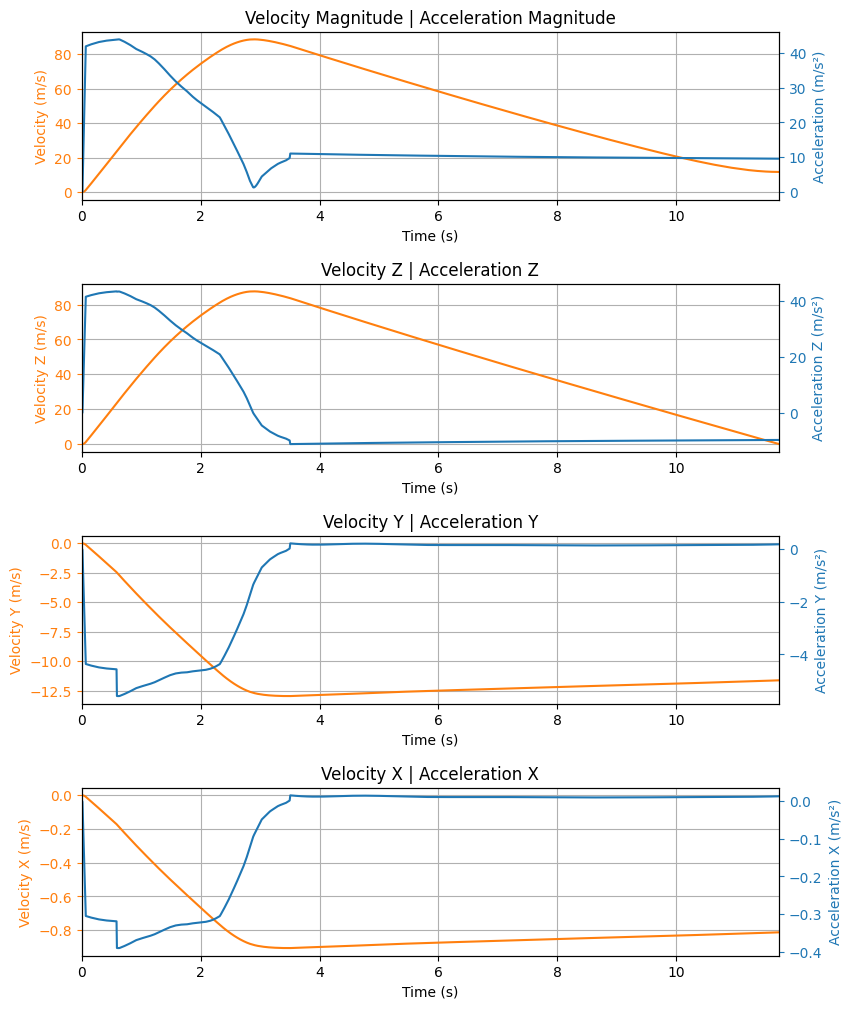



Angular Position Plots



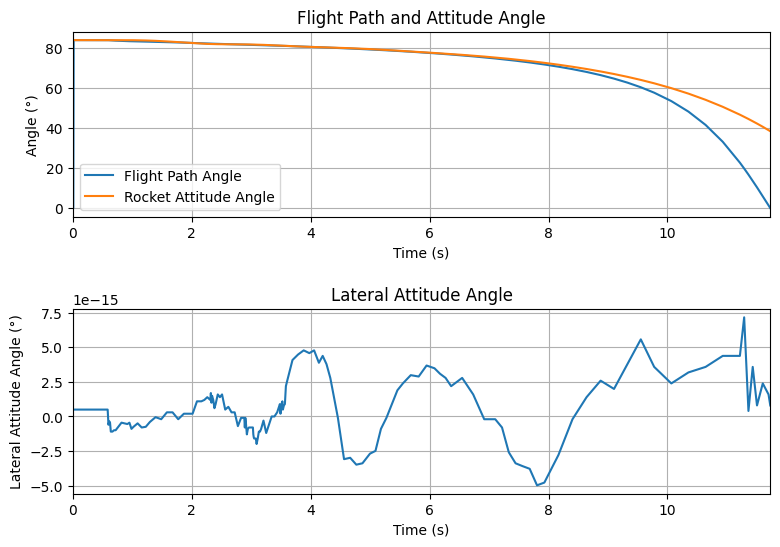



Path, Attitude and Lateral Attitude Angle plots



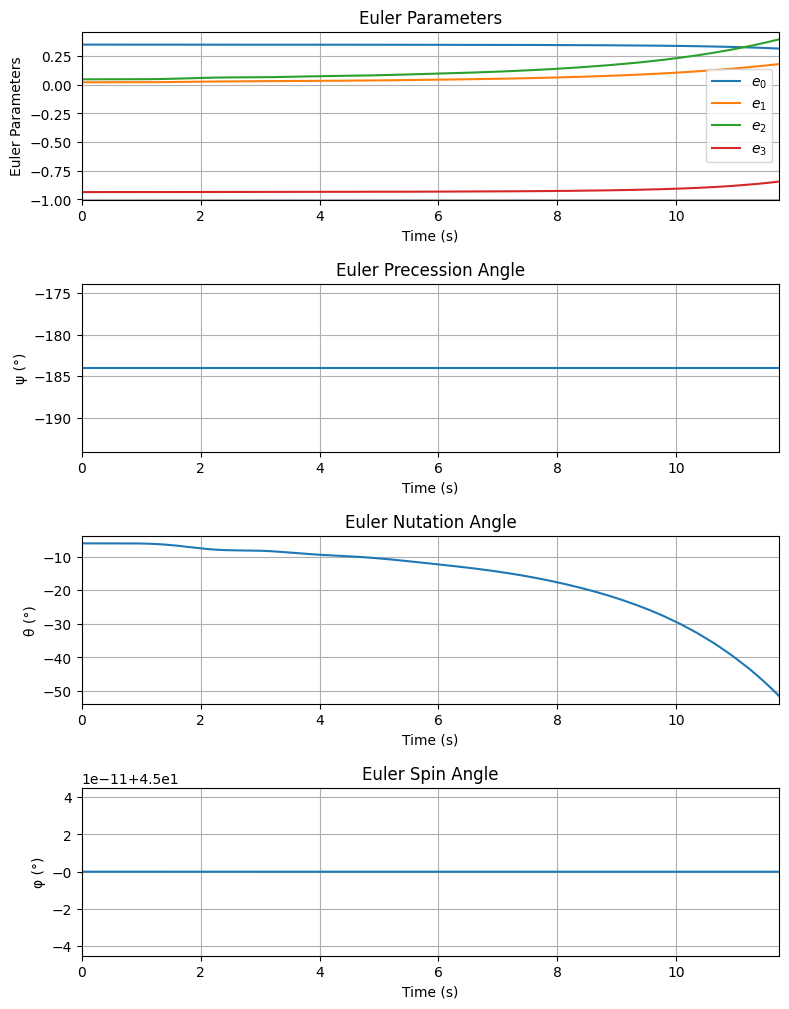



Trajectory Angular Velocity and Acceleration Plots



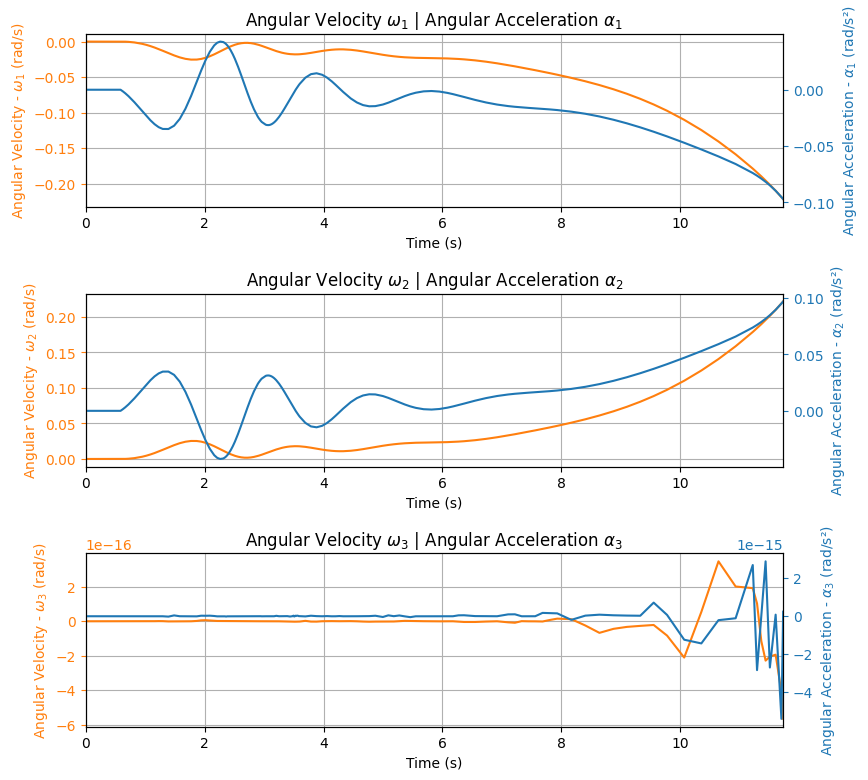



Aerodynamic Forces Plots



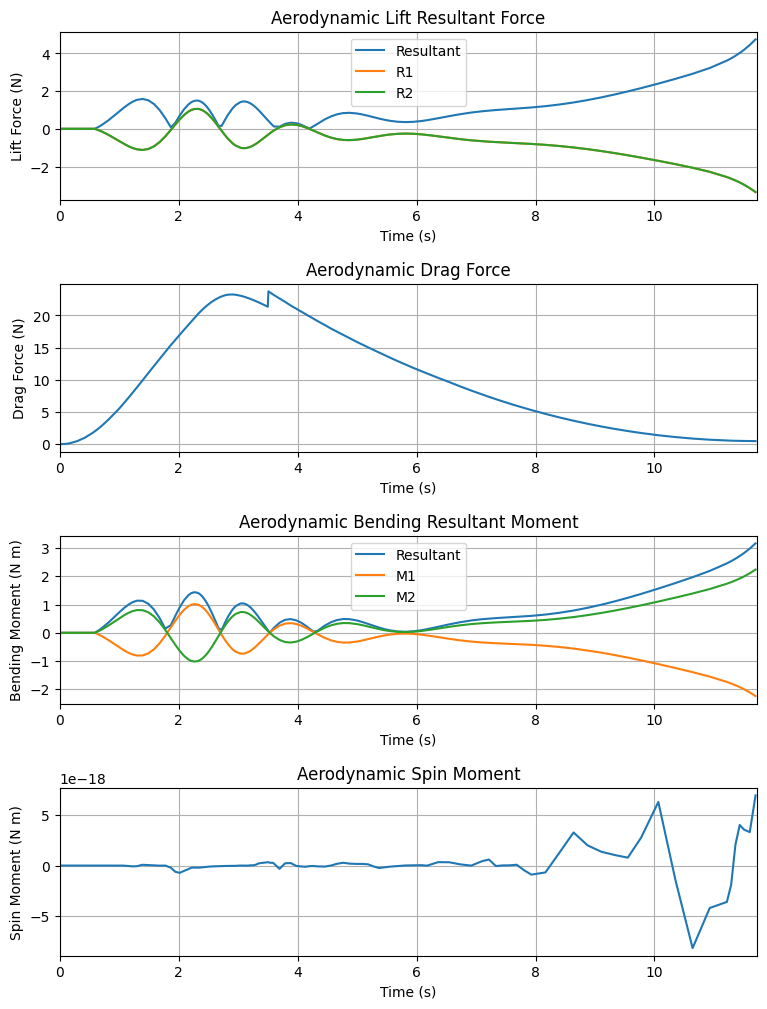



Rail Buttons Forces Plots



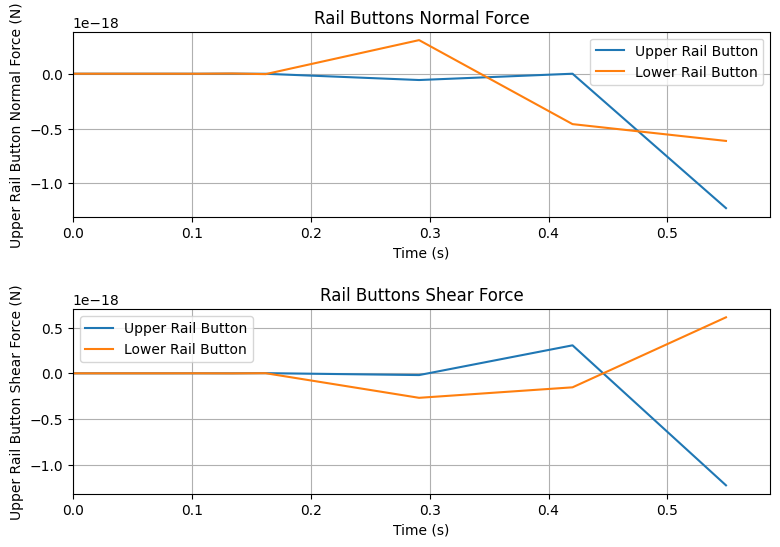



Trajectory Energy Plots



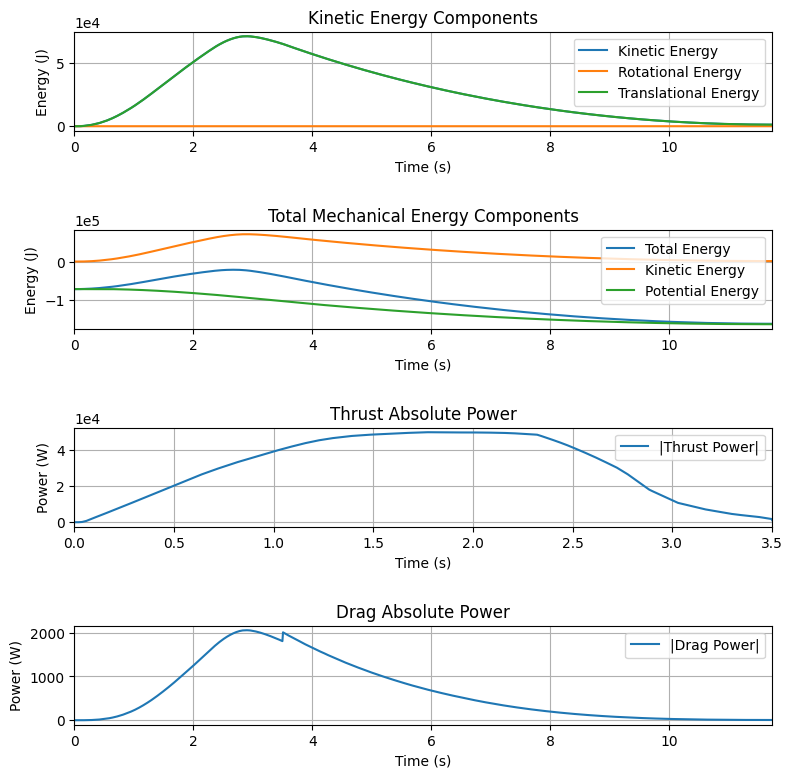



Trajectory Fluid Mechanics Plots



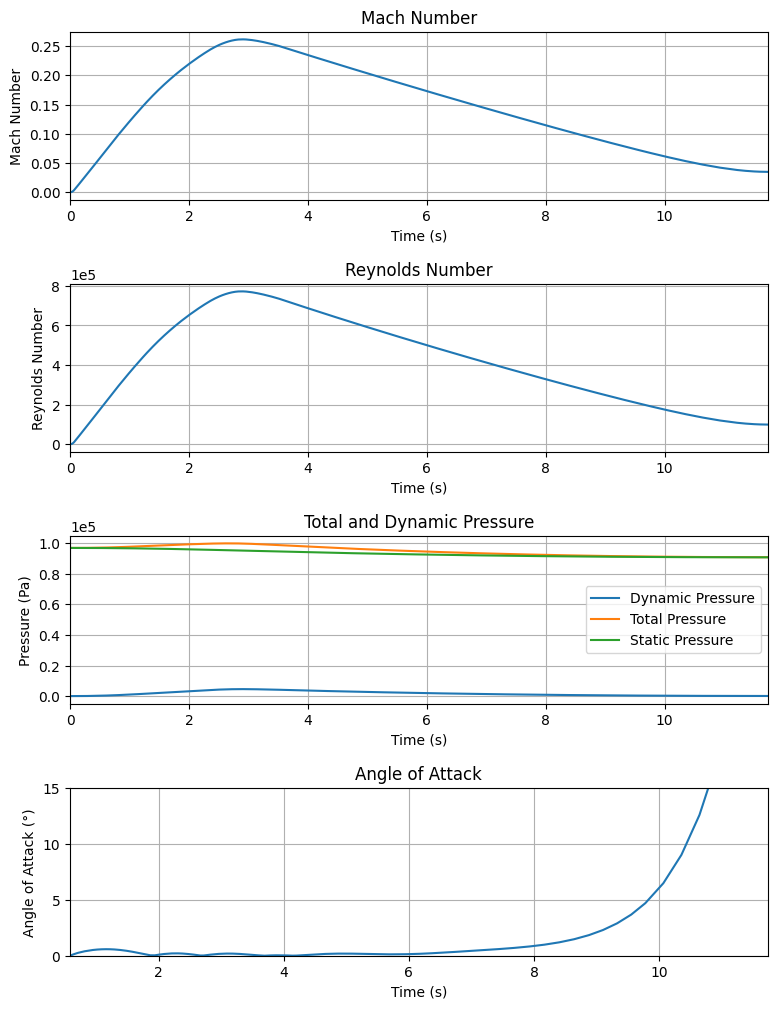



Trajectory Stability and Control Plots



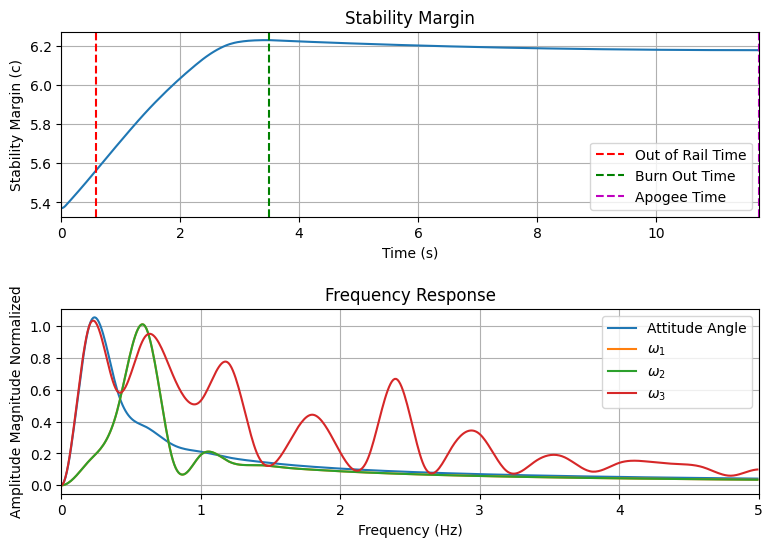



Rocket and Parachute Pressure Plots



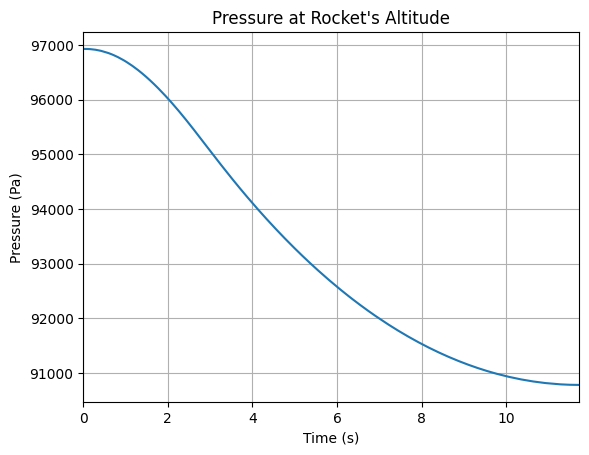


Rocket has no parachutes. No parachute plots available
File  trajectory.kml  saved with success!


In [12]:
rail_length           = flight_config["rail_length"]
inclination           = flight_config["inclination"]
heading               = flight_config["heading"]
terminate_on_apogee   = flight_config["terminate_on_apogee"]

flight_forecast = Flight(
          rocket        = hedy,
          environment   = envForecast,
          rail_length   = rail_length,
          inclination   = inclination,
          heading       = heading,
          terminate_on_apogee = terminate_on_apogee,
          name          = "Reanalysis"
  )
print(f"Takeoff Mass: {hedy.total_mass(flight_forecast.out_of_rail_time)}")
#flight_forecast.prints.out_of_rail_conditions()
#flight_forecast.prints.apogee_conditions()
#flight_forecast.prints.impact_conditions()
#flight_forecast.prints.maximum_values()
#flight_forecast.plots.trajectory_3d()
#flight_forecast.plots.stability_and_control_data()

#flight_forecast.prints.all()
#flight_forecast.plots.all()



flight_forecast.all_info()

flight_forecast.export_kml()


## Comparsion

### Initialization

In [500]:
from rocketpy.simulation.flight_data_importer import FlightDataImporter
from rocketpy import Function


def pressure_to_altitude(data):
    return 0.3048 * ((1 - (data / 1013.25) ** 0.190284) * 145366.45) # reference: https://www.weather.gov/media/epz/wxcalc/pressureAltitude.pdf


columns_map_cats_vega = {
    "ts": "time",
    "filteredAltitudeAGL": "altitude",
    "filteredAcceleration": "az",
    "latitude": "latitude",
    "longitude": "longitude",
    "Ax":"acceleration_x",
    "Ay":"acceleration_y",
    "Az":"acceleration_z",
    "Gx":"gyro_x",
    "Gy":"gyro_y",
    "Gz":"gyro_z",
    "velocity":"speed",
    "P": "pressure"

}

cats_vega_flight = FlightDataImporter(
    name="CATS Vega Flight Data",
    paths=["CATS FLIGHT DATA/filteredDataInfo.csv","CATS FLIGHT DATA/gnssInfo.csv","CATS FLIGHT DATA/flightInfo.csv","CATS FLIGHT DATA/imu.csv","CATS FLIGHT DATA/baro.csv"],
    columns_map=columns_map_cats_vega,
    units=None,
    interpolation="linear",
    extrapolation="zero",
    delimiter=",",
    encoding="utf-8",
)


columns_map_altimax = {
    "ZEIT":"time",
    "PRESS_FILTER":"pressure",
    "HEIGHT_FILTER":"altitude",
    "ACCEL":"acceleration",
    "SPEED":"speed"
}

altimax_flight = FlightDataImporter(
    name="Altimax Flight Data",
    paths=["ALTIMAX FLIGHT DATA/Hedy_Flug_EuRoC.csv"],
    columns_map=columns_map_altimax,
    units=None,
    interpolation="linear",
    extrapolation="zero",
    delimiter=",",
    encoding="utf-8",
)


columns_map_rcu = {
    "time":"time",
    "lora:gps_altitude:sensor":"altitude",
    "lora:gps_latitude:sensor":"latitude",
    "lora:gps_longitude:sensor":"longitude",
    "lora:gps_status:sensor":"gps_status",
    "lora:rcu_accel_x:sensor":"accel_x",
    "lora:rcu_accel_y:sensor":"accel_y",
    "lora:rcu_accel_z:sensor":"accel_z",
    "lora:rcu_gyro_x:sensor":"gyro_x",
    "lora:rcu_gyro_y:sensor":"gyro_y",
    "lora:rcu_gyro_z:sensor":"gyro_z",
    "lora:rcu_barometer:sensor":"pressure"
}

srad_flight = FlightDataImporter(
    name="SRAD Flight Data",
    paths=["RCU FLIGHT DATA/2025-10-12_EuRoC_launch_filtered.csv"],
    columns_map=columns_map_rcu,
    units=None,
    interpolation="linear",
    extrapolation="constant",
    delimiter=",",
    encoding="utf-8",
)

The following attributes were create and are now available to be used:  ['time', 'altitude', 'az']
The following attributes were create and are now available to be used:  ['time', 'latitude', 'longitude']
The following attributes were create and are now available to be used:  ['time', 'speed']
The following attributes were create and are now available to be used:  ['time', 'acceleration_x', 'acceleration_y', 'acceleration_z', 'gyro_x', 'gyro_y', 'gyro_z']
The following attributes were create and are now available to be used:  ['time', 'pressure']
The following attributes were create and are now available to be used:  ['time', 'pressure', 'altitude', 'acceleration', 'speed']
The following attributes were create and are now available to be used:  ['time', 'altitude', 'latitude', 'longitude', 'gps_status', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'pressure']


### Altitude

Actual apogee: 5279.38 m
Simulated apogee: 5406.91 m
Error: 127.53 m
Percentage Error: 2.42%


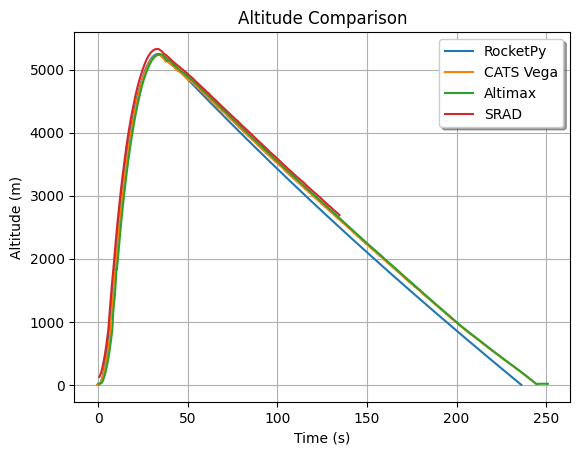

In [501]:
data = srad_flight.pressure
altitude_srad = Function(data[np.isfinite(data[:,0]) & np.isfinite(data[:,1])])


apogee_srad = pressure_to_altitude(altitude_srad.min)

apogee_actual = (apogee_srad + cats_vega_flight.altitude.max) /2
apogee_simulated = flight_reanalysis.apogee
apogee_error = abs(apogee_actual - apogee_simulated)
apogee_percentage_error = apogee_error / apogee_actual * 100

print(f"Actual apogee: {apogee_actual:.2f} m")
print(f"Simulated apogee: {apogee_simulated:.2f} m")
print(f"Error: {apogee_error:.2f} m")
print(f"Percentage Error: {apogee_percentage_error:.2f}%")


Function.compare_plots(
    [
        (flight_reanalysis.altitude, "RocketPy"),
        (cats_vega_flight.altitude, "CATS Vega"),
        (altimax_flight.altitude, "Altimax"),
        (pressure_to_altitude(altitude_srad), "SRAD")
    ],
    title="Altitude Comparison",
    xlabel="Time (s)",
    ylabel="Altitude (m)",
)

### GNSS

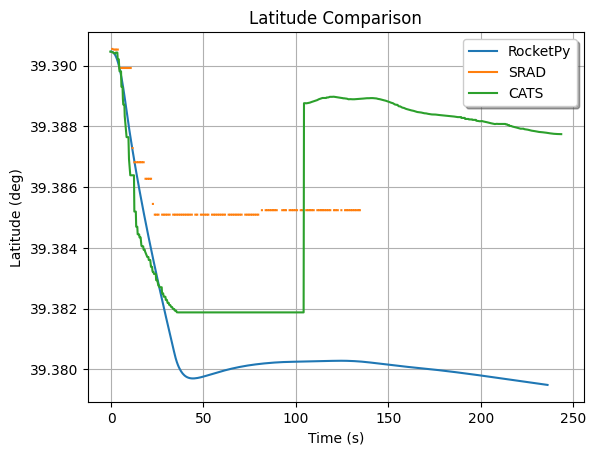

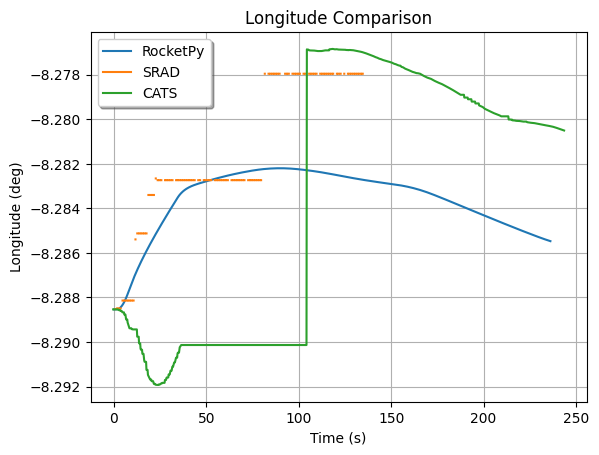

In [502]:
Function.compare_plots(
    [
        (flight_reanalysis.latitude, "RocketPy"),
        (srad_flight.latitude, "SRAD"),
        (cats_vega_flight.latitude, "CATS")
    ],
    title="Latitude Comparison",
    xlabel="Time (s)",
    ylabel="Latitude (deg)",
)
Function.compare_plots(
    [
        (flight_reanalysis.longitude, "RocketPy"),
        (srad_flight.longitude, "SRAD"),
        (cats_vega_flight.longitude, "CATS")
    ],
    title="Longitude Comparison",
    xlabel="Time (s)",
    ylabel="Longitude (deg)",
)

### Pressure

Actual min pressure: 51521.53 Pa
Simulated min pressure: 52452.64 Pa
Error: 931.11 Pa
Percentage Error: 1.81%


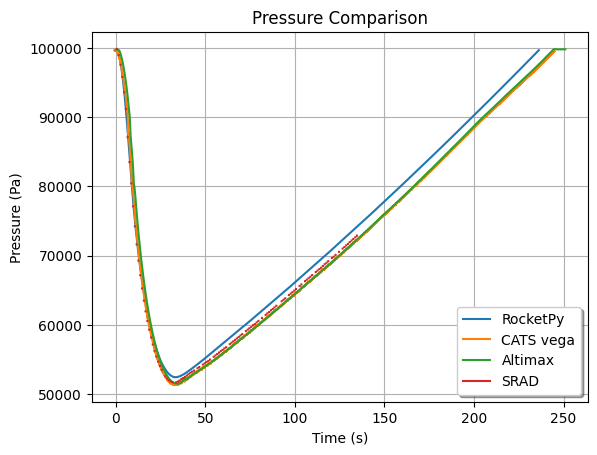

In [503]:
pressure_actual = altimax_flight.pressure.min
pressure_simulated = flight_reanalysis.pressure.min
pressure_error = abs(pressure_actual - pressure_simulated)
pressure_percentage_error = pressure_error / pressure_actual * 100

print(f"Actual min pressure: {pressure_actual:.2f} Pa")
print(f"Simulated min pressure: {pressure_simulated:.2f} Pa")
print(f"Error: {pressure_error:.2f} Pa")
print(f"Percentage Error: {pressure_percentage_error:.2f}%")


Function.compare_plots(
    [
        (flight_reanalysis.pressure, "RocketPy"),
        (cats_vega_flight.pressure, "CATS vega"),
        (altimax_flight.pressure, "Altimax"),
        (srad_flight.pressure*100, "SRAD")
    ],
    title="Pressure Comparison",
    xlabel="Time (s)",
    ylabel="Pressure (Pa)",
)

### Acceleration

Actual max acceleration during burn: 66.22 m/s2
Simulated max acceleration during burn: 55.42 m/s2
Error: 10.80 m/s2
Percentage Error: 16.30%


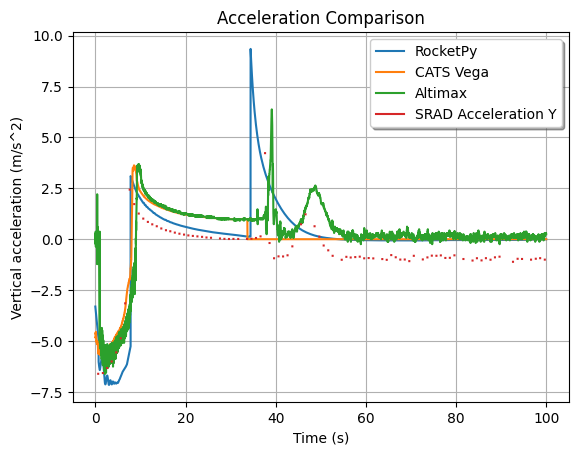

In [504]:
acceleration_actual = altimax_flight.acceleration.crop([(0, 20)]).max
acceleration_simulated = flight_reanalysis.acceleration.crop([(0, 20)]).max
acceleration_error = abs(acceleration_actual - acceleration_simulated)
acceleration_percentage_error = acceleration_error / acceleration_actual * 100

print(f"Actual max acceleration during burn: {acceleration_actual:.2f} m/s2")
print(f"Simulated max acceleration during burn: {acceleration_simulated:.2f} m/s2")
print(f"Error: {acceleration_error:.2f} m/s2")
print(f"Percentage Error: {acceleration_percentage_error:.2f}%")

Function.compare_plots(
    [
        (flight_reanalysis.ay.crop([(0, 100)]), "RocketPy"),
        (cats_vega_flight.az.crop([(0, 100)]) /10 *(-1), "CATS Vega"),
        (altimax_flight.acceleration.crop([(0, 100)]) /10 *(-1), "Altimax"),
        (srad_flight.accel_y.crop([(0, 100)]), "SRAD Acceleration Y")
    ],
    title="Acceleration Comparison",
    xlabel="Time (s)",
    ylabel="Vertical acceleration (m/s^2)",
)

### Speed

Actual max speed: 365.15 m/s2
Simulated max speed: 365.66 m/s2
Error: 0.51 m/s2
Percentage Error: 0.14%


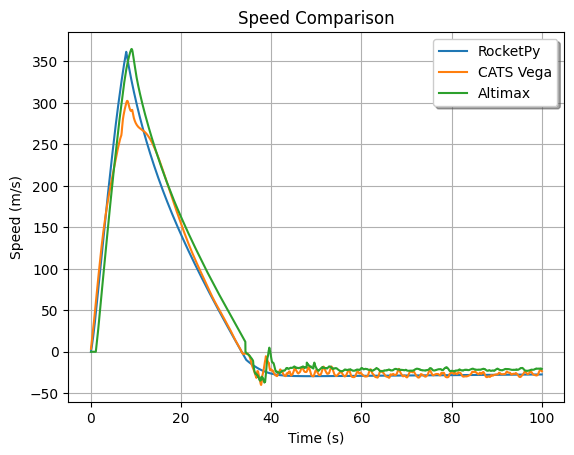

In [505]:
speed_actual = altimax_flight.speed.max
speed_simulated = flight_reanalysis.speed.max
speed_error = abs(speed_actual - speed_simulated)
speed_percentage_error = speed_error /speed_actual * 100

print(f"Actual max speed: {speed_actual:.2f} m/s2")
print(f"Simulated max speed: {speed_simulated:.2f} m/s2")
print(f"Error: {speed_error:.2f} m/s2")
print(f"Percentage Error: {speed_percentage_error:.2f}%")

Function.compare_plots(
    [
        (flight_reanalysis.vz.crop([(0, 100)]), "RocketPy"),
        (cats_vega_flight.speed.crop([(0, 100)]), "CATS Vega"),
        (altimax_flight.speed.crop([(0, 100)]), "Altimax")
    ],
    title="Speed Comparison",
    xlabel="Time (s)",
    ylabel="Speed (m/s)",
)